# Two-clock learning-budget allocation experiment

**Status:** exploratory experiment. This notebook validates the complete experiment and figure pipeline; the allocation-strategy comparison is descriptive rather than confirmatory because its best off-diagonal strategies are selected after observing the same trial outcomes.

We compare learning an action-sensitive controllable clock, $x$, with learning an action-invariant predictable clock, $y$. The primary diagnostic is terminal success after planning under posterior-sampled transition models and evaluating matched rollouts in the true environment. Each trial evaluates navigation once per $N_x$ and records that outcome across $N_y$; synchronization is evaluated once per $(N_x,N_y)$ pair. Target navigation should depend on $N_x$ but be exactly invariant to $N_y$ under the matched design. Clock synchronization can depend on both.

## Model and terminal tasks

Both clocks live on the ring $\mathbb Z_M$ and the hand action is $a\in\{\mathrm{left},\mathrm{right},\mathrm{stay}\}$. If $g_z$ is a factor's intended successor, then

$$
P(z'=g_z)=q,
\qquad
P(z'=u)=\frac{1-q}{M-1}\quad(u\ne g_z).
$$

For $x$, the action selects left, right, or stay. For $y$, the experimenter selects one fixed direction and the true row is identical for every action. Each policy takes exactly $H$ actions before receiving one of two binary terminal rewards:

$$
R_H^{\mathrm{target}}=\mathbf 1[x_H=g],
\qquad
R_H^{\mathrm{sync}}=\mathbf 1[x_H=y_H].
$$

In [1]:
from __future__ import annotations

import math
import os
import platform
import sys
import tempfile
import time
from pathlib import Path

# Use a writable, deterministic cache location before importing Matplotlib.
os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "evolving-world-models-matplotlib"),
)

import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from scripts.clock_experiment import (
    HAND_ACTIONS,
    NAVIGATION_TASK,
    SYNCHRONIZATION_TASK,
    ClockExperimentConfig,
    build_clock_beliefs,
    build_clock_world,
    read_summary_csv,
    read_trial_csv,
    run_clock_experiment,
    select_allocation_strategies,
    verify_run_manifest,
    write_clock_experiment,
    write_run_manifest,
)
from scripts.experiment_plotting import (
    plot_allocation_sensitivity,
    plot_success_heatmaps,
)


def discover_repository_root(start: Path):
    """Return the checkout root when the notebook is launched inside it."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "scripts").is_dir():
            return candidate
    return None


repository_root = discover_repository_root(Path.cwd())
output_base = Path.cwd() if repository_root is None else repository_root
artifact_base_label = "working directory" if repository_root is None else "repository root"

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Matplotlib:", matplotlib.__version__)
print("Artifact base:", artifact_base_label)

Python: 3.12.13
Platform: Linux-5.14.0-503.40.1.el9_5.x86_64-x86_64-with-glibc2.34
Matplotlib: 3.11.1
Artifact base: working directory


## Explicit configuration

Scientific parameters and presentation parameters are intentionally separate. Runtime grows with the state count, horizon, trial count, and allocation grid. Treat changes to the scientific parameters as a new run, and predeclare uncertainty and success criteria before using a run as confirmatory evidence.

In [2]:
# Scientific configuration
M = 6
Q = 0.80
PREDICTABLE_DIRECTION = "right"
H = 30
T = 100
N_X_VALUES = (0, 1, 2, 3, 4)
N_Y_VALUES = (0, 1, 2, 3, 4)
FIXED_TOTAL_BUDGETS = (2, 4, 6)
ALPHA = 1.0
MASTER_SEED = 20260723

config = ClockExperimentConfig(
    num_states=M,
    intended_probability=Q,
    predictable_direction=PREDICTABLE_DIRECTION,
    horizon=H,
    trials=T,
    x_updates=N_X_VALUES,
    y_updates=N_Y_VALUES,
    fixed_total_budgets=FIXED_TOTAL_BUDGETS,
    prior_concentration=ALPHA,
    master_seed=MASTER_SEED,
)

# Presentation configuration; changing these does not change measurements.
NAVIGATION_COLORMAP = "viridis"
SYNCHRONIZATION_COLORMAP = "plasma"

config.to_dict()

{'schema_version': 'two-clock-config-v1',
 'num_states': 6,
 'intended_probability': 0.8,
 'predictable_direction': 'right',
 'horizon': 30,
 'trials': 100,
 'x_updates': [0, 1, 2, 3, 4],
 'y_updates': [0, 1, 2, 3, 4],
 'fixed_total_budgets': [2, 4, 6],
 'prior_concentration_per_outcome': 1.0,
 'master_seed': 20260723,
 'hand_actions': ['left', 'right', 'stay'],
 'contexts_per_factor': 18,
 'seed_derivation': 'sha256(canonical-json(master_seed, namespace))[:8]'}

## Exhaustive true-kernel checks

The checks below cover every state and action. They verify modulo-$M$ intended successors, the shared residual distribution, normalization, and true action invariance of $y$.

In [3]:
world = build_clock_world(config)
residual_probability = (1.0 - Q) / (M - 1)
displacement = {"left": -1, "right": 1, "stay": 0}

for state in range(M):
    for action in HAND_ACTIONS:
        x_distribution = world.x_factor.transition_distribution(
            {"x": state}, {"hand": action}
        )
        intended_x = (state + displacement[action]) % M
        for next_state in range(M):
            expected = Q if next_state == intended_x else residual_probability
            assert math.isclose(
                x_distribution.probability({"x": next_state}), expected
            )
        assert math.isclose(
            math.fsum(probability for _, probability in x_distribution.items()),
            1.0,
        )

    y_rows = [
        world.y_factor.transition_distribution({"y": state}, {"hand": action}).items()
        for action in HAND_ACTIONS
    ]
    assert y_rows[0] == y_rows[1] == y_rows[2]
    intended_y = (state + displacement[PREDICTABLE_DIRECTION]) % M
    for next_state in range(M):
        expected = Q if next_state == intended_y else residual_probability
        probability = world.y_factor.transition_probability(
            {"y": next_state}, {"y": state}, {"hand": "left"}
        )
        assert math.isclose(probability, expected)

print(f"Validated {2 * 3 * M} true local rows over {M} next states each.")

Validated 36 true local rows over 6 next states each.


## Beliefs and budget accounting

$N_x$ and $N_y$ are updates per factor-local `(state, action)` row, not trajectory steps. Both beliefs have $3M$ rows and $M$ next-state outcomes per row. One cell therefore spends $3M(N_x+N_y)$ local updates.

In [4]:
beliefs = build_clock_beliefs(config, world)
assert len(beliefs.x.counts) == 3 * M
assert len(beliefs.y.counts) == 3 * M
assert all(len(row) == M and set(row.values()) == {0} for row in beliefs.x.counts.values())
assert all(len(row) == M and set(row.values()) == {0} for row in beliefs.y.counts.values())
assert beliefs.model.parent_variables == (world.hand,)

budget_rows = [
    {
        "N_x": n_x,
        "N_y": n_y,
        "N_x + N_y": n_x + n_y,
        "local updates per trial": config.total_local_updates(n_x, n_y),
    }
    for n_y in config.y_updates
    for n_x in config.x_updates
]
budget_rows

[{'N_x': 0, 'N_y': 0, 'N_x + N_y': 0, 'local updates per trial': 0},
 {'N_x': 1, 'N_y': 0, 'N_x + N_y': 1, 'local updates per trial': 18},
 {'N_x': 2, 'N_y': 0, 'N_x + N_y': 2, 'local updates per trial': 36},
 {'N_x': 3, 'N_y': 0, 'N_x + N_y': 3, 'local updates per trial': 54},
 {'N_x': 4, 'N_y': 0, 'N_x + N_y': 4, 'local updates per trial': 72},
 {'N_x': 0, 'N_y': 1, 'N_x + N_y': 1, 'local updates per trial': 18},
 {'N_x': 1, 'N_y': 1, 'N_x + N_y': 2, 'local updates per trial': 36},
 {'N_x': 2, 'N_y': 1, 'N_x + N_y': 3, 'local updates per trial': 54},
 {'N_x': 3, 'N_y': 1, 'N_x + N_y': 4, 'local updates per trial': 72},
 {'N_x': 4, 'N_y': 1, 'N_x + N_y': 5, 'local updates per trial': 90},
 {'N_x': 0, 'N_y': 2, 'N_x + N_y': 2, 'local updates per trial': 36},
 {'N_x': 1, 'N_y': 2, 'N_x + N_y': 3, 'local updates per trial': 54},
 {'N_x': 2, 'N_y': 2, 'N_x + N_y': 4, 'local updates per trial': 72},
 {'N_x': 3, 'N_y': 2, 'N_x + N_y': 5, 'local updates per trial': 90},
 {'N_x': 4, 'N_y': 2,

## Run, persist, and reload

Each top-level trial uses nested context-specific observation streams, samples factor models with seeds that exclude the opposite budget, and plans with exact backward induction. It executes one navigation rollout per $N_x$, reusing that matched outcome across $N_y$, and one synchronization rollout per $(N_x,N_y)$ pair. The figure is constructed only after reloading the saved summary.

In [5]:
run_started = time.perf_counter()
result = run_clock_experiment(config)
elapsed_seconds = time.perf_counter() - run_started

artifacts = write_clock_experiment(
    result,
    output_base / "results" / "two-clock",
)
saved_trials = read_trial_csv(artifacts.trials_path)
saved_summaries = read_summary_csv(artifacts.summary_path)

expected_trials = 2 * T * len(N_X_VALUES) * len(N_Y_VALUES)
expected_summaries = 2 * len(N_X_VALUES) * len(N_Y_VALUES)
assert len(saved_trials) == expected_trials
assert len(saved_summaries) == expected_summaries
assert all(record.success in (0, 1) for record in saved_trials)
assert all(summary.trials == T for summary in saved_summaries)
assert saved_trials == result.trials
assert saved_summaries == result.summaries

# The navigation task is an exact negative control for N_y.
for trial_id in range(T):
    for n_x in N_X_VALUES:
        matched = [
            record
            for record in saved_trials
            if record.task == NAVIGATION_TASK
            and record.trial_id == trial_id
            and record.n_x == n_x
        ]
        assert len({
            (
                record.success,
                record.final_x,
                record.x_model_seed,
                record.tie_seed,
                record.rollout_x_seed,
            )
            for record in matched
        }) == 1

print(f"Completed {len(saved_trials)} binary evaluations in {elapsed_seconds:.3f} s.")
print("Run directory:", artifacts.run_directory.relative_to(output_base))

Completed 5000 binary evaluations in 846.696 s.
Run directory: results/two-clock/two-clock-20260723T222025252737Z-69ce6650bd38


## Saved cell summaries

The primary estimate is $k/T$. Wilson 95% binomial intervals and Monte Carlo standard errors remain in `summary.csv` and the compact table below rather than being encoded as additional heatmaps.

In [6]:
summary_table = [
    {
        "task": summary.task,
        "N_x": summary.n_x,
        "N_y": summary.n_y,
        "successes/T": f"{summary.successes}/{summary.trials}",
        "mean": round(summary.success_probability, 3),
        "Wilson 95%": (
            round(summary.wilson_95_lower, 3),
            round(summary.wilson_95_upper, 3),
        ),
    }
    for summary in saved_summaries
]
summary_table

[{'task': 'navigation',
  'N_x': 0,
  'N_y': 0,
  'successes/T': '15/100',
  'mean': 0.15,
  'Wilson 95%': (0.093, 0.233)},
 {'task': 'navigation',
  'N_x': 1,
  'N_y': 0,
  'successes/T': '32/100',
  'mean': 0.32,
  'Wilson 95%': (0.237, 0.417)},
 {'task': 'navigation',
  'N_x': 2,
  'N_y': 0,
  'successes/T': '42/100',
  'mean': 0.42,
  'Wilson 95%': (0.328, 0.518)},
 {'task': 'navigation',
  'N_x': 3,
  'N_y': 0,
  'successes/T': '51/100',
  'mean': 0.51,
  'Wilson 95%': (0.413, 0.606)},
 {'task': 'navigation',
  'N_x': 4,
  'N_y': 0,
  'successes/T': '54/100',
  'mean': 0.54,
  'Wilson 95%': (0.443, 0.634)},
 {'task': 'navigation',
  'N_x': 0,
  'N_y': 1,
  'successes/T': '15/100',
  'mean': 0.15,
  'Wilson 95%': (0.093, 0.233)},
 {'task': 'navigation',
  'N_x': 1,
  'N_y': 1,
  'successes/T': '32/100',
  'mean': 0.32,
  'Wilson 95%': (0.237, 0.417)},
 {'task': 'navigation',
  'N_x': 2,
  'N_y': 1,
  'successes/T': '42/100',
  'mean': 0.42,
  'Wilson 95%': (0.328, 0.518)},
 {'task'

## Terminal success heatmaps

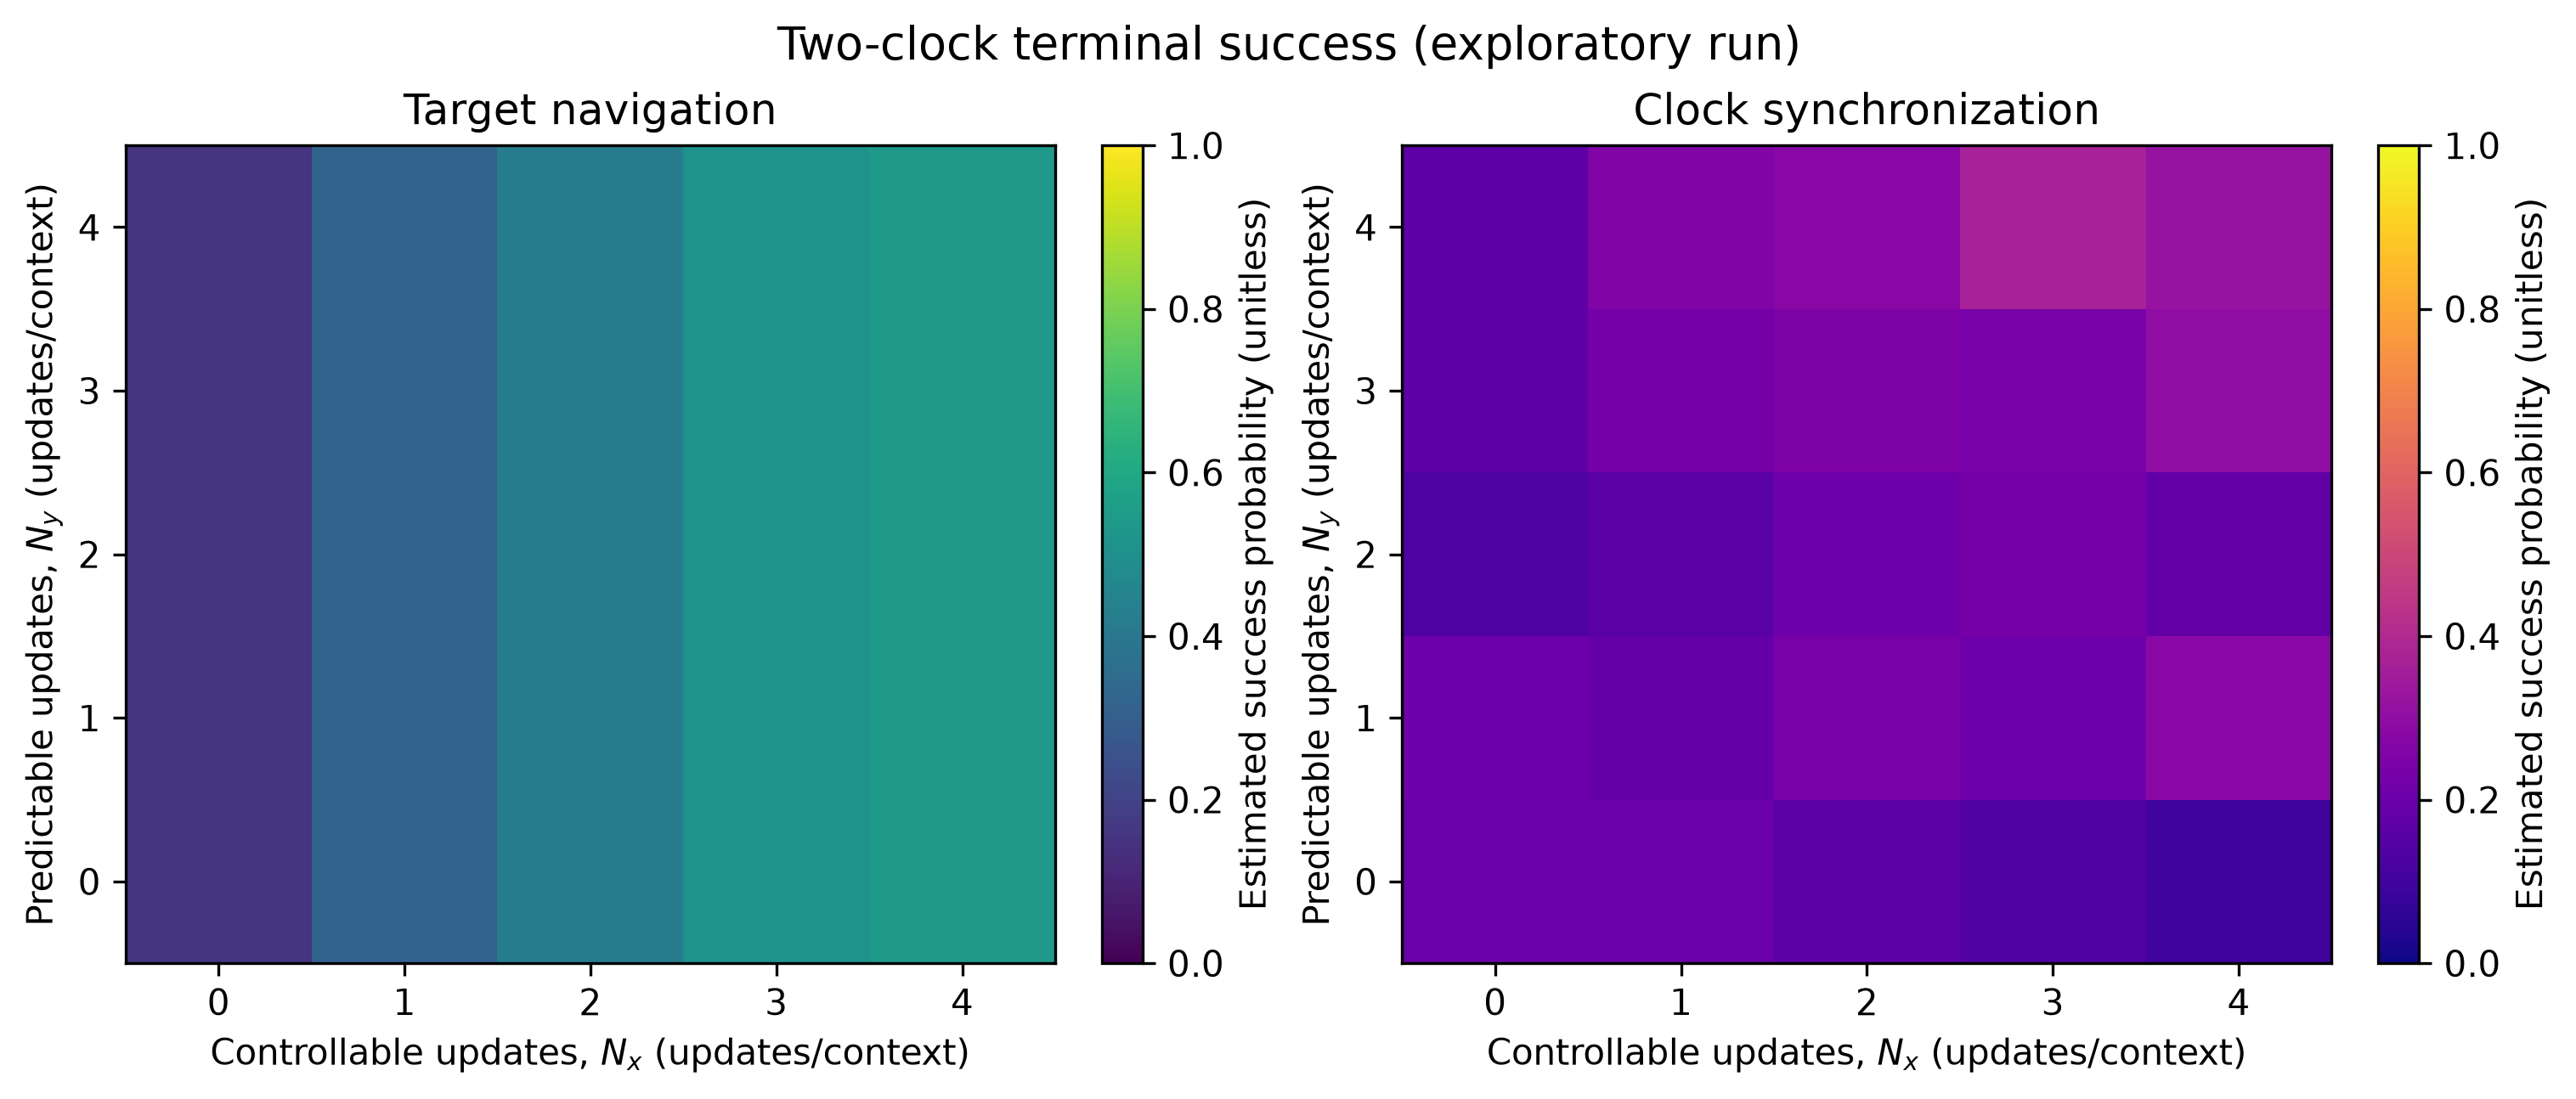

**Figure 1. Terminal task success.** Each cell is the fraction of T=100 independent trial groups ending in the binary goal for M=6, q=0.8, predictable direction=right, H=30, alpha=1.0, and master seed=20260723. N_x and N_y count updates per factor-local (state, action) context. Observation streams use matched nested prefixes. Navigation has one rollout per N_x reused across N_y; synchronization has one rollout per (N_x, N_y) pair. Both color scales span 0 to 1 and higher is better. Wilson 95% intervals are reported in the saved summary table. These results are exploratory, not confirmatory evidence.

In [7]:
figure, axes = plot_success_heatmaps(
    saved_summaries,
    navigation_colormap=NAVIGATION_COLORMAP,
    synchronization_colormap=SYNCHRONIZATION_COLORMAP,
)
figure.suptitle("Two-clock terminal success (exploratory run)", fontsize=13)

pdf_path = artifacts.figures_directory / "two-clock-success.pdf"
png_path = artifacts.figures_directory / "two-clock-success.png"
figure.savefig(pdf_path, bbox_inches="tight")
figure.savefig(png_path, dpi=300, bbox_inches="tight")
write_run_manifest(artifacts.run_directory)
verify_run_manifest(artifacts.run_directory)

display(figure)
plt.close(figure)

caption = (
    f"**Figure 1. Terminal task success.** Each cell is the fraction of T={T} "
    f"independent trial groups ending in the binary goal for M={M}, q={Q}, "
    f"predictable direction={PREDICTABLE_DIRECTION}, H={H}, alpha={ALPHA}, "
    f"and master seed={MASTER_SEED}. N_x and N_y count updates per factor-local "
    "(state, action) context. Observation streams use matched nested prefixes. "
    "Navigation has one rollout per N_x reused across N_y; synchronization has "
    "one rollout per (N_x, N_y) pair. Both "
    "color scales span 0 to 1 and higher is better. Wilson 95% intervals are "
    "reported in the saved summary table. These results are exploratory, not "
    "confirmatory evidence."
)
display(Markdown(caption))

## Allocation sensitivity across total budgets

For each fixed total $N=N_x+N_y$, we compare equal allocation $(N/2,N/2)$ with two descriptive oracle envelopes: the best observed below-diagonal cell ($N_x>N_y$, more updates for the controllable clock) and the best observed above-diagonal cell ($N_x<N_y$, more updates for the predictable clock). Ties prefer the allocation nearest the diagonal, then the smaller $(N_x,N_y)$ pair.

The two best curves are selected after inspecting the same outcomes plotted here. They diagnose sensitivity among observed allocation strategies; they are not prospective strategy estimates, and their pointwise Wilson intervals are not adjusted for selection.

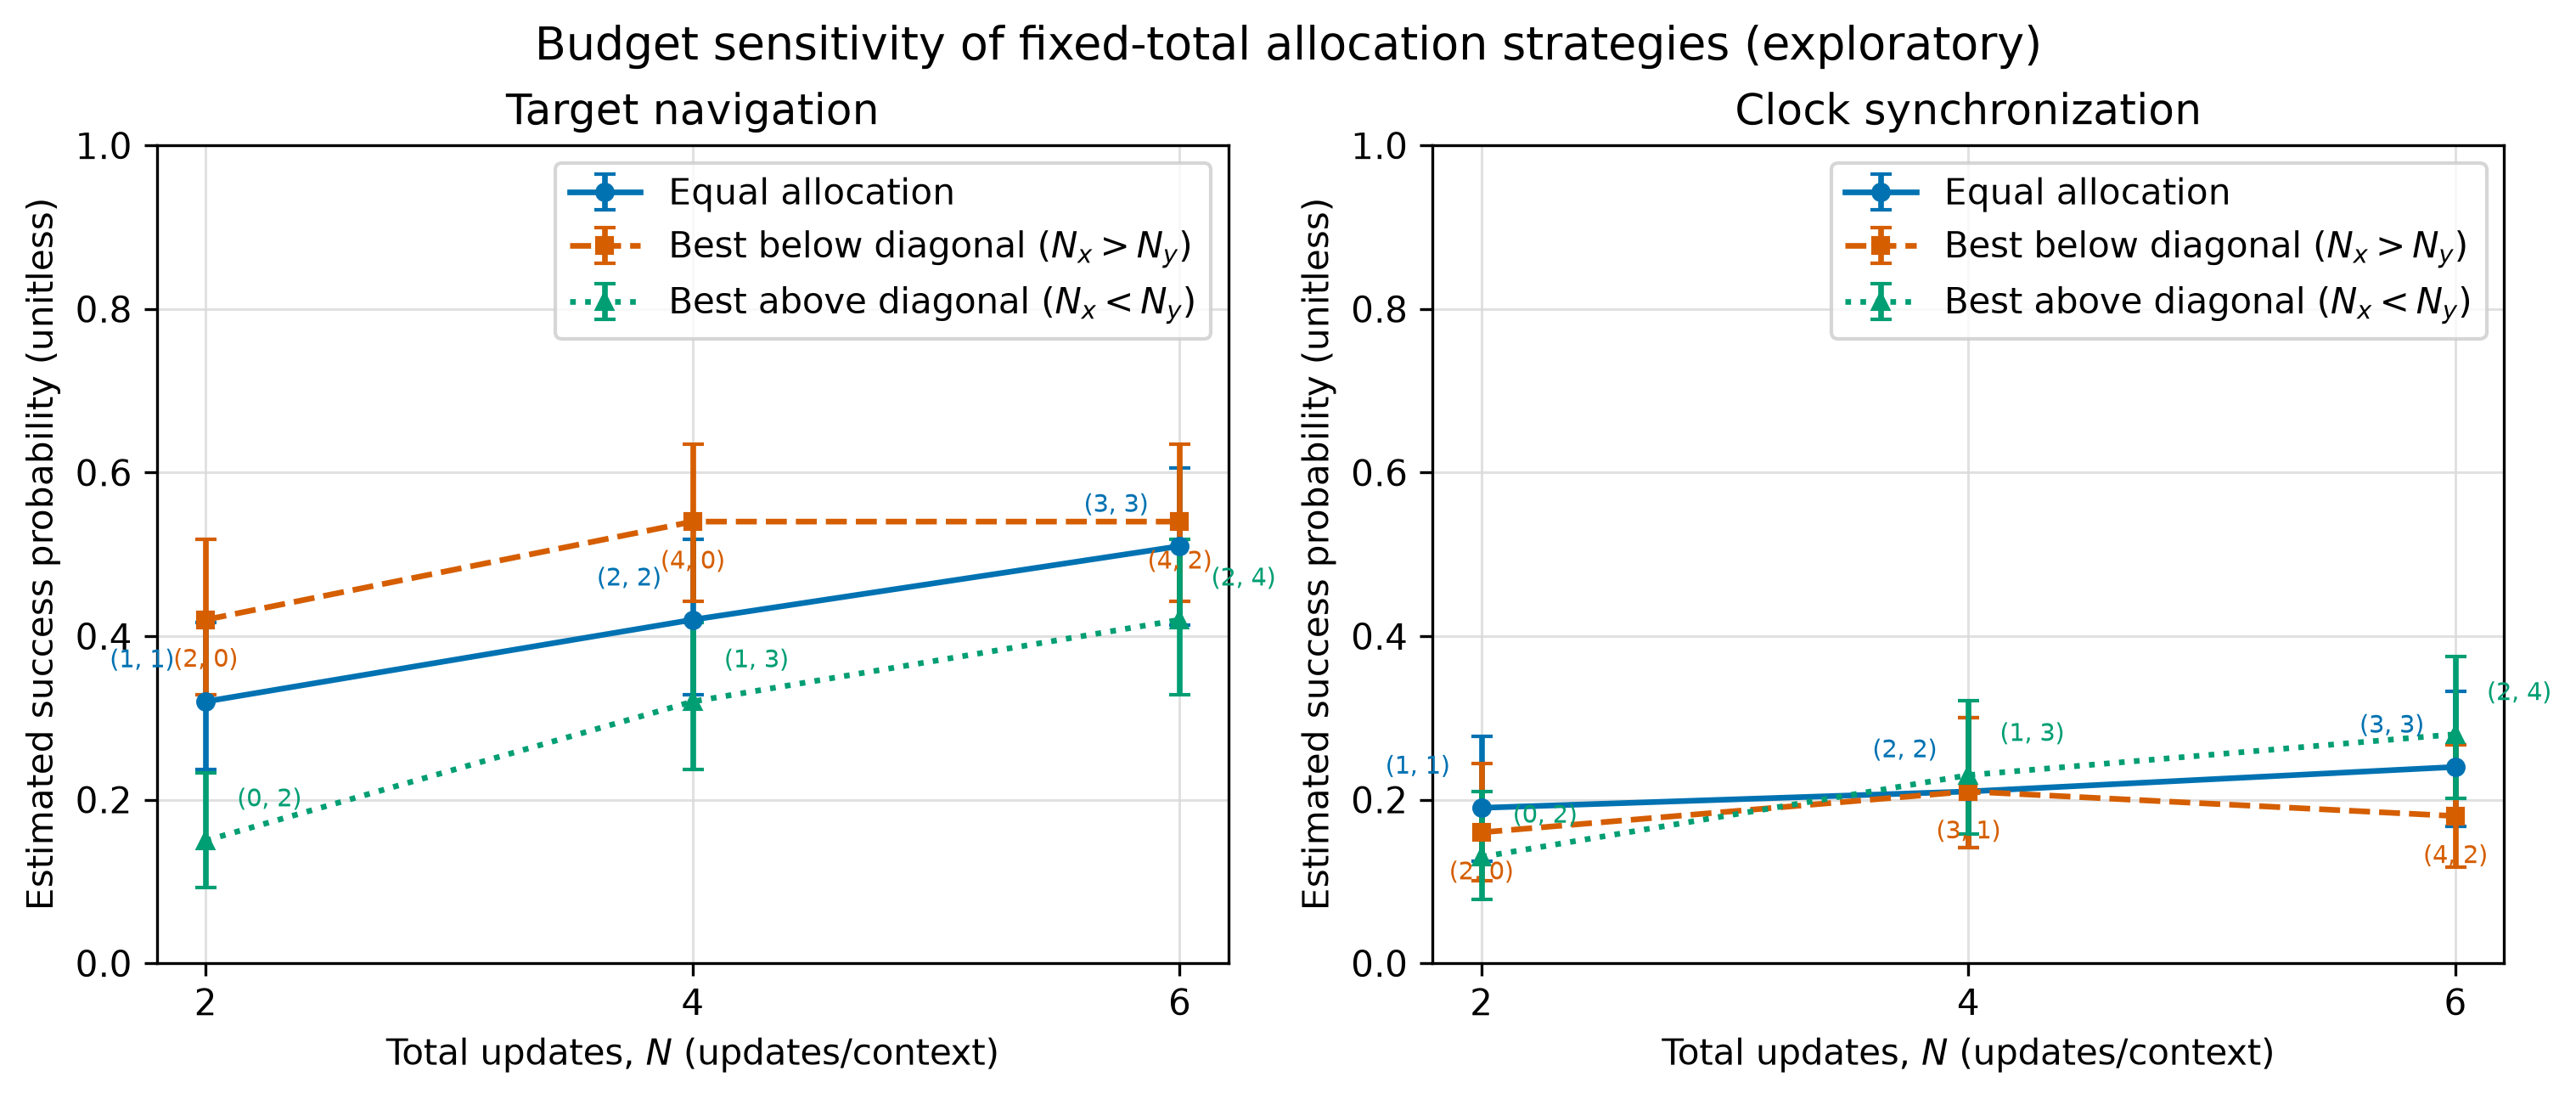

**Figure 2. Allocation sensitivity to total observation budget.** For each task and even total $N=N_x+N_y$, equal allocation is compared with the highest observed success rate below the diagonal ($N_x>N_y$) and above the diagonal ($N_x<N_y$). Point labels report the selected $(N_x,N_y)$ allocation. Each estimate aggregates T=100 matched trial groups for M=6, q=0.8, predictable direction=right, H=30, alpha=1.0, and master seed=20260723; higher is better. Error bars are pointwise Wilson 95% binomial intervals. The best off-diagonal curves are post-hoc oracle envelopes, and their intervals do not account for selection, so this figure is a descriptive sensitivity diagnostic rather than a prospective comparison.

In [8]:
allocation_points = select_allocation_strategies(
    saved_summaries,
    FIXED_TOTAL_BUDGETS,
)
assert len(allocation_points) == 2 * len(FIXED_TOTAL_BUDGETS) * 3

sensitivity_figure, sensitivity_axes = plot_allocation_sensitivity(
    allocation_points,
)
sensitivity_figure.suptitle(
    "Budget sensitivity of fixed-total allocation strategies (exploratory)",
    fontsize=13,
)

sensitivity_pdf_path = artifacts.figures_directory / "allocation-sensitivity.pdf"
sensitivity_png_path = artifacts.figures_directory / "allocation-sensitivity.png"
sensitivity_figure.savefig(sensitivity_pdf_path, bbox_inches="tight")
sensitivity_figure.savefig(
    sensitivity_png_path,
    dpi=300,
    bbox_inches="tight",
)
write_run_manifest(artifacts.run_directory)
verify_run_manifest(artifacts.run_directory)

display(sensitivity_figure)
plt.close(sensitivity_figure)

sensitivity_caption = (
    f"**Figure 2. Allocation sensitivity to total observation budget.** For each "
    f"task and even total $N=N_x+N_y$, equal allocation is compared with the "
    f"highest observed success rate below the diagonal ($N_x>N_y$) and above the "
    f"diagonal ($N_x<N_y$). Point labels report the selected $(N_x,N_y)$ allocation. "
    f"Each estimate aggregates T={T} matched trial groups for M={M}, q={Q}, "
    f"predictable direction={PREDICTABLE_DIRECTION}, H={H}, alpha={ALPHA}, and "
    f"master seed={MASTER_SEED}; higher is better. Error bars are pointwise Wilson "
    f"95% binomial intervals. The best off-diagonal curves are post-hoc oracle "
    f"envelopes, and their intervals do not account for selection, so this figure "
    f"is a descriptive sensitivity diagnostic rather than a prospective comparison."
)
display(Markdown(sensitivity_caption))

## Interpretation and limitations

The exhaustive assertions and exact $N_y$ invariance of the navigation records validate the intended implementation contracts. The displayed success rates remain descriptive: the off-diagonal curves maximize over observed cells and therefore have an optimistic selection bias that their pointwise Wilson intervals do not quantify.

The learner intentionally does not pool the known shared reliability, ring translations, or true action invariance of $y$. Balanced row sampling represents allocation of belief-update capacity rather than physical online interaction. Posterior-sampled planning need not improve monotonically at every finite cell, and the synchronization task depends materially on $M$, $H$, the initial-state distribution, and the selected predictable direction.

A confirmatory run should predeclare the candidate strategy for every total budget, the trial count, a success criterion, a durable artifact location, and the expected uncertainty before inspecting outcomes. A nested run should then estimate those fixed strategies on independent evaluation trial groups rather than selecting and evaluating each winner on the same data.

In [9]:
manifest_entries = sorted(
    path.relative_to(artifacts.run_directory).as_posix()
    for path in artifacts.run_directory.rglob("*")
    if path.is_file()
)
print("Verified artifacts:")
for entry in manifest_entries:
    print(" -", entry)

Verified artifacts:
 - config.json
 - figures/allocation-sensitivity.pdf
 - figures/allocation-sensitivity.png
 - figures/two-clock-success.pdf
 - figures/two-clock-success.png
 - manifest.json
 - seeds.csv
 - summary.csv
 - trials.csv
